In [ ]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Load the Dataset 
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)


In [3]:
# select numerical features 
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features].copy()

print(X.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [4]:
# Handle invalid or missing values 
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=features
)

print("Missing values after preprocessing:")
print(X_imputed.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [5]:
# Standardize the features 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Features standardized successfully.")

Features standardized successfully.


c:\Users\temp.admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\temp.admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\temp.admin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\temp.admin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\temp.admin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid

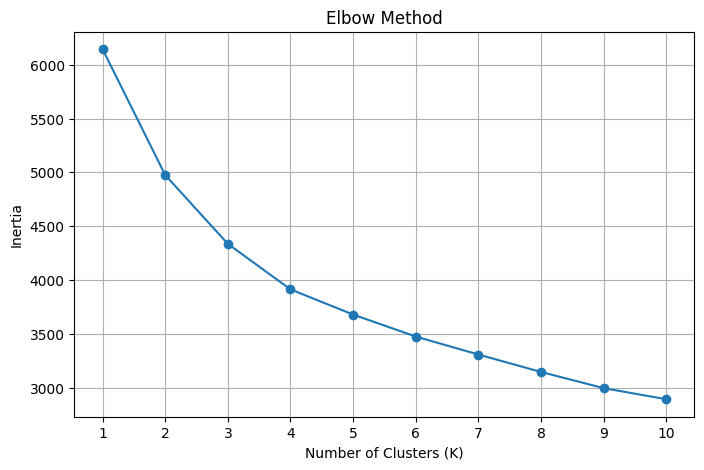

In [7]:
# Aplly the elbow method 
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [8]:
# Apply K-means Clustering
chosen_k = 3

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

X_imputed["Cluster"] = clusters

print("Cluster assignments:")
print(X_imputed[["Cluster"]].head(10))

print("\nNumber of observations in each cluster:")
print(X_imputed["Cluster"].value_counts().sort_index())

Cluster assignments:
   Cluster
0        0
1        1
2        0
3        1
4        2
5        1
6        1
7        0
8        2
9        0

Number of observations in each cluster:
Cluster
0    248
1    335
2    185
Name: count, dtype: int64


In [9]:
# Evaluate using the Silhouette Score 
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19500407738247363


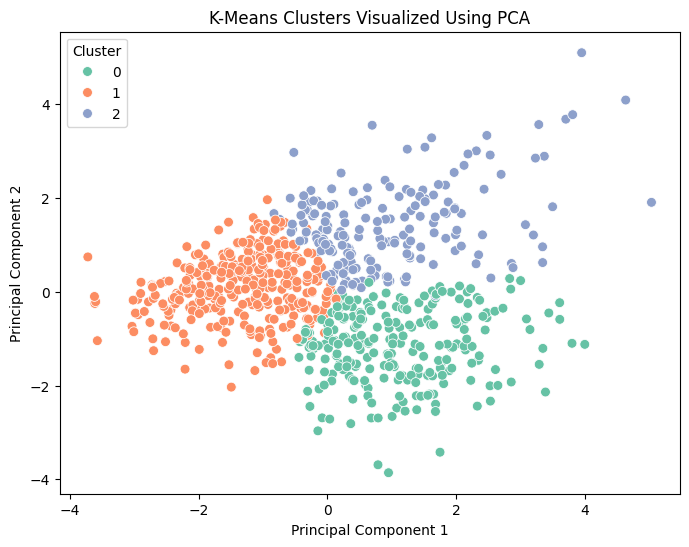

In [10]:
# Apply PCA and visualize the clusters 
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Cluster": clusters
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=50
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [11]:
# Analyze and interpret the clusters 
cluster_data = X_imputed.copy()
cluster_data["Cluster"] = clusters

cluster_summary = cluster_data.groupby("Cluster").mean().round(2)

print("Average Values for Each Cluster:")
print(cluster_summary)

Average Values for Each Cluster:
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Cluster                                                                       
0               7.37   130.79          78.42          30.02   139.63  32.81   
1               2.28   106.62          66.76          24.21   113.33  28.50   
2               1.95   136.64          74.49          36.76   191.57  39.15   

         DiabetesPedigreeFunction    Age  
Cluster                                   
0                            0.46  46.04  
1                            0.41  25.94  
2                            0.60  29.30  


In [12]:
print("Number of observations in each cluster:")
print(cluster_data["Cluster"].value_counts().sort_index())

Number of observations in each cluster:
Cluster
0    248
1    335
2    185
Name: count, dtype: int64
